# Notebook 07: ViT Comparison and Efficiency — Main19

This notebook evaluates a Vision Transformer (ViT-B/16) against the completed
CNN models under the same Main19 data protocol.

## Protocol

- Training: `main19_train.csv` only
- Model selection and early stopping: `main19_calibration.csv` only
- Test set: `main19_internal_test.csv`, used once for the selected ViT checkpoint
- Primary model-selection metric: calibration macro-F1
- Primary final comparison metric: internal-test macro-F1

This notebook compares:

1. EfficientNet-B0 baseline
2. EfficientNetV2-S proposed CNN
3. ViT-B/16 transformer

The internal test set must not be used to tune ViT architecture, augmentation,
learning rate, batch size, epoch count, or model-selection criteria.

In [1]:
import os
import gc
import json
import random
import time
import platform
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageFile
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    log_loss
)

ImageFile.LOAD_TRUNCATED_IMAGES = True

SEED = 7

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("PyTorch:", torch.__version__)
print("Torchvision:", __import__("torchvision").__version__)

if DEVICE.type == "cuda":
    GPU_NAME = torch.cuda.get_device_name(0)
    GPU_CAPABILITY = torch.cuda.get_device_capability(0)
    GPU_MEMORY_GB = (
        torch.cuda.get_device_properties(0).total_memory / 1024**3
    )

    print("GPU:", GPU_NAME)
    print("CUDA capability:", GPU_CAPABILITY)
    print("GPU memory (GB):", round(GPU_MEMORY_GB, 2))

    assert GPU_CAPABILITY >= (7, 0), (
        f"{GPU_NAME} has capability {GPU_CAPABILITY}. "
        "Select a Tesla T4 or newer GPU."
    )
else:
    raise RuntimeError(
        "GPU not detected. Enable a Tesla T4 GPU before training."
    )

Device: cuda
PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
GPU: Tesla T4
CUDA capability: (7, 5)
GPU memory (GB): 14.56


In [2]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 12,

    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "axes.linewidth": 1.2,

    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,

    "legend.fontsize": 11,
    "legend.frameon": True,
    "legend.edgecolor": "0.4",

    "grid.linestyle": ":",
    "grid.linewidth": 0.7,
    "grid.alpha": 0.85,
})


def paper_axes(ax):
    ax.minorticks_on()

    ax.grid(
        True,
        which="major",
        linestyle=":",
        linewidth=0.8
    )

    ax.grid(
        True,
        which="minor",
        linestyle=":",
        linewidth=0.5,
        alpha=0.7
    )

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

    ax.tick_params(
        which="both",
        direction="in",
        top=True,
        right=True
    )


print("Professional paper plotting style enabled.")

Professional paper plotting style enabled.


In [3]:
INPUT_ROOT = Path("/kaggle/input")
WORK_DIR = Path("/kaggle/working")

OUTPUT_DIR = WORK_DIR / "vit_comparison_and_efficiency_outputs"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
METADATA_DIR = OUTPUT_DIR / "metadata"

for folder in [
    OUTPUT_DIR,
    CHECKPOINT_DIR,
    FIG_DIR,
    TABLE_DIR,
    METADATA_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Input root:", INPUT_ROOT)
print("Output directory:", OUTPUT_DIR)

Input root: /kaggle/input
Output directory: /kaggle/working/vit_comparison_and_efficiency_outputs


In [4]:
def find_input_file(file_name, required=True):
    matches = list(INPUT_ROOT.rglob(file_name))

    if len(matches) == 0:
        if required:
            raise FileNotFoundError(
                f"Could not locate '{file_name}' under /kaggle/input."
            )
        return None

    if len(matches) > 1:
        print(f"\nMultiple matches found for: {file_name}")
        for match in matches:
            print(" -", match)

        print("Using first match:", matches[0])

    return matches[0]


TRAIN_MANIFEST_PATH = find_input_file("main19_train.csv")
CALIBRATION_MANIFEST_PATH = find_input_file(
    "main19_calibration.csv"
)
TEST_MANIFEST_PATH = find_input_file(
    "main19_internal_test.csv"
)
CLASS_MAPPING_PATH = find_input_file(
    "class_to_index_main19.json"
)
PROTOCOL_PATH = find_input_file("data_protocol.json")

BASELINE_METRICS_PATH = find_input_file(
    "main19_temperature_scaling_metrics.csv",
    required=False
)

PROPOSED_METRICS_PATH = find_input_file(
    "proposed_model_temperature_scaling_metrics.csv",
    required=False
)

print("\nTrain manifest:", TRAIN_MANIFEST_PATH)
print("Calibration manifest:", CALIBRATION_MANIFEST_PATH)
print("Internal-test manifest:", TEST_MANIFEST_PATH)
print("Class mapping:", CLASS_MAPPING_PATH)
print("Data protocol:", PROTOCOL_PATH)
print("Baseline metrics:", BASELINE_METRICS_PATH)
print("Proposed CNN metrics:", PROPOSED_METRICS_PATH)


Train manifest: /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/manifests/main19/main19_train.csv
Calibration manifest: /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/manifests/main19/main19_calibration.csv
Internal-test manifest: /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/manifests/main19/main19_internal_test.csv
Class mapping: /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/metadata/class_to_index_main19.json
Data protocol: /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/metadata/data_protocol.json
Baseline metrics: /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/nb_05/nb_05/main19_temperature_scaling_metrics.csv
Proposed CNN metrics: /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/nb_06/nb_06/proposed_model_temperature_scaling_metrics.csv


In [5]:
train_df = pd.read_csv(TRAIN_MANIFEST_PATH)
calibration_df = pd.read_csv(CALIBRATION_MANIFEST_PATH)
test_df = pd.read_csv(TEST_MANIFEST_PATH)

with open(CLASS_MAPPING_PATH, "r") as file:
    class_to_index = json.load(file)

with open(PROTOCOL_PATH, "r") as file:
    data_protocol = json.load(file)

class_to_index = {
    str(label): int(index)
    for label, index in class_to_index.items()
}

index_to_class = {
    int(index): label
    for label, index in class_to_index.items()
}

NUM_CLASSES = len(class_to_index)

required_columns = {
    "image_path",
    "label",
    "final_split"
}

for dataframe_name, dataframe in [
    ("train", train_df),
    ("calibration", calibration_df),
    ("internal test", test_df)
]:
    missing_columns = required_columns - set(dataframe.columns)

    assert not missing_columns, (
        f"{dataframe_name} manifest missing: {missing_columns}"
    )

assert set(train_df["final_split"]) == {"train"}
assert set(calibration_df["final_split"]) == {"calibration"}
assert set(test_df["final_split"]) == {"internal_test"}

assert train_df["label"].nunique() == NUM_CLASSES == 19
assert calibration_df["label"].nunique() == NUM_CLASSES
assert test_df["label"].nunique() == NUM_CLASSES

assert set(train_df["label"]) == set(class_to_index)
assert set(calibration_df["label"]) == set(class_to_index)
assert set(test_df["label"]) == set(class_to_index)

assert set(train_df["image_path"]).isdisjoint(
    set(calibration_df["image_path"])
)

assert set(train_df["image_path"]).isdisjoint(
    set(test_df["image_path"])
)

assert set(calibration_df["image_path"]).isdisjoint(
    set(test_df["image_path"])
)

assert train_df["image_path"].nunique() == len(train_df)
assert calibration_df["image_path"].nunique() == len(calibration_df)
assert test_df["image_path"].nunique() == len(test_df)

print("Train images:", len(train_df))
print("Calibration images:", len(calibration_df))
print("Internal-test images:", len(test_df))
print("Classes:", NUM_CLASSES)

print("\nPASS: All manifests are valid and mutually disjoint.")

Train images: 18113
Calibration images: 3197
Internal-test images: 5322
Classes: 19

PASS: All manifests are valid and mutually disjoint.


In [6]:
train_exists = train_df["image_path"].map(
    lambda path: Path(path).exists()
)

calibration_exists = calibration_df["image_path"].map(
    lambda path: Path(path).exists()
)

test_exists = test_df["image_path"].map(
    lambda path: Path(path).exists()
)

print("Train files found:", int(train_exists.sum()), "/", len(train_df))
print(
    "Calibration files found:",
    int(calibration_exists.sum()),
    "/",
    len(calibration_df)
)
print("Test files found:", int(test_exists.sum()), "/", len(test_df))

assert train_exists.all()
assert calibration_exists.all()
assert test_exists.all()

print("\nPASS: All source image paths exist.")

Train files found: 18113 / 18113
Calibration files found: 3197 / 3197
Test files found: 5322 / 5322

PASS: All source image paths exist.


In [7]:
protocol_record = {
    "notebook": "07_vit_comparison_and_efficiency",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "seed": SEED,
    "model": "ViT-B/16",
    "train_images": int(len(train_df)),
    "calibration_images": int(len(calibration_df)),
    "internal_test_images": int(len(test_df)),
    "classes": int(NUM_CLASSES),
    "checkpoint_selection_metric": "calibration macro-F1",
    "internal_test_usage": (
        "One final evaluation after checkpoint selection"
    ),
    "confirmed_near_duplicate_exclusions": data_protocol.get(
        "confirmed_near_duplicate_exclusions",
        "not_recorded"
    )
}

protocol_record_path = METADATA_DIR / "vit_protocol_record.json"

with open(protocol_record_path, "w") as file:
    json.dump(protocol_record, file, indent=2)

print(json.dumps(protocol_record, indent=2))

{
  "notebook": "07_vit_comparison_and_efficiency",
  "created_utc": "2026-08-22T12:50:58.849364+00:00",
  "seed": 7,
  "model": "ViT-B/16",
  "train_images": 18113,
  "calibration_images": 3197,
  "internal_test_images": 5322,
  "classes": 19,
  "checkpoint_selection_metric": "calibration macro-F1",
  "internal_test_usage": "One final evaluation after checkpoint selection",
  "confirmed_near_duplicate_exclusions": 2
}


In [8]:
ordered_labels = sorted(
    class_to_index,
    key=class_to_index.get
)

class_counts = (
    train_df["label"]
    .value_counts()
    .reindex(ordered_labels)
)

class_weight_values = len(train_df) / (
    NUM_CLASSES * class_counts.values.astype(np.float32)
)

class_weights = torch.tensor(
    class_weight_values,
    dtype=torch.float32,
    device=DEVICE
)

class_weight_df = pd.DataFrame({
    "class_index": [
        class_to_index[label]
        for label in ordered_labels
    ],
    "label": ordered_labels,
    "train_images": class_counts.values,
    "class_weight": class_weight_values
})

class_weight_path = TABLE_DIR / "vit_training_class_weights.csv"
class_weight_df.to_csv(class_weight_path, index=False)

display(class_weight_df)

print("Smallest class:", int(class_counts.min()))
print("Largest class:", int(class_counts.max()))
print(
    "Largest/smallest ratio:",
    round(float(class_counts.max() / class_counts.min()), 2)
)

,class_index,label,train_images,class_weight
0,0,bell_pepper__bacterial_spot,677,1.408147
1,1,bell_pepper__healthy,1005,0.948573
2,2,corn__cercospora_leaf_spot_gray_leaf_spot,348,2.739413
3,3,corn__common_rust,810,1.176933
4,4,corn__healthy,790,1.206729
5,5,corn__northern_leaf_blight,670,1.422859
6,6,potato__early_blight,680,1.401935
7,7,potato__healthy,103,9.255493
8,8,potato__late_blight,680,1.401935
9,9,tomato__bacterial_spot,1447,0.658822


Smallest class: 103
Largest class: 3643
Largest/smallest ratio: 35.37


In [9]:
IMAGE_SIZE = 224

TRAIN_TRANSFORM = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.80, 1.00),
        ratio=(0.90, 1.10)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=12),
    transforms.ColorJitter(
        brightness=0.12,
        contrast=0.12,
        saturation=0.08,
        hue=0.02
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    transforms.RandomErasing(
        p=0.10,
        scale=(0.02, 0.06),
        ratio=(0.30, 3.30),
        value="random"
    )
])

EVAL_TRANSFORM = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("ViT input size:", IMAGE_SIZE, "x", IMAGE_SIZE)

ViT input size: 224 x 224


In [10]:
class PlantDiseaseDataset(Dataset):
    def __init__(self, dataframe, class_to_index, transform):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.class_to_index = class_to_index
        self.transform = transform

        self.image_paths = self.dataframe["image_path"].tolist()
        self.labels = self.dataframe["label"].tolist()

        self.targets = [
            self.class_to_index[label]
            for label in self.labels
        ]

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        image_path = self.image_paths[index]
        target = self.targets[index]

        try:
            with Image.open(image_path) as image:
                image = image.convert("RGB")
        except Exception as error:
            raise RuntimeError(
                f"Could not load image at index {index}: {image_path}"
            ) from error

        image = self.transform(image)

        return {
            "image": image,
            "target": torch.tensor(target, dtype=torch.long),
            "path": image_path
        }


train_dataset = PlantDiseaseDataset(
    train_df,
    class_to_index,
    TRAIN_TRANSFORM
)

calibration_dataset = PlantDiseaseDataset(
    calibration_df,
    class_to_index,
    EVAL_TRANSFORM
)

test_dataset = PlantDiseaseDataset(
    test_df,
    class_to_index,
    EVAL_TRANSFORM
)

print("Train dataset:", len(train_dataset))
print("Calibration dataset:", len(calibration_dataset))
print("Internal-test dataset:", len(test_dataset))

Train dataset: 18113
Calibration dataset: 3197
Internal-test dataset: 5322


In [11]:
BATCH_SIZE = 16
NUM_WORKERS = min(4, os.cpu_count() or 2)
PIN_MEMORY = DEVICE.type == "cuda"

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
    generator=loader_generator
)

calibration_loader = DataLoader(
    calibration_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0
)

print("Batch size:", BATCH_SIZE)
print("Workers:", NUM_WORKERS)
print("Train batches:", len(train_loader))
print("Calibration batches:", len(calibration_loader))
print("Test batches:", len(test_loader))

Batch size: 16
Workers: 4
Train batches: 1133
Calibration batches: 200
Test batches: 333


In [12]:
try:
    vit_weights = models.ViT_B_16_Weights.IMAGENET1K_V1

    model = models.vit_b_16(
        weights=vit_weights
    )

    print("Loaded ImageNet-pretrained ViT-B/16 weights.")

except Exception as error:
    raise RuntimeError(
        "Could not load ViT-B/16 pretrained weights. "
        "Enable Internet or attach compatible PyTorch weights."
    ) from error

classifier_features = model.heads.head.in_features

model.heads.head = nn.Sequential(
    nn.Dropout(p=0.30),
    nn.Linear(classifier_features, NUM_CLASSES)
)

model = model.to(DEVICE)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Total parameters:", f"{total_parameters:,}")
print("Trainable parameters:", f"{trainable_parameters:,}")
print(model.heads)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 176MB/s]


Loaded ImageNet-pretrained ViT-B/16 weights.
Total parameters: 85,813,267
Trainable parameters: 85,813,267
Sequential(
  (head): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=768, out_features=19, bias=True)
  )
)


In [13]:
EPOCHS = 15
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 4
MAX_GRAD_NORM = 1.0

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.05
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=1,
    min_lr=1e-6
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=DEVICE.type == "cuda"
)

vit_training_config = {
    "architecture": "ViT-B/16",
    "pretrained_weights": "IMAGENET1K_V1",
    "input_size": IMAGE_SIZE,
    "num_classes": NUM_CLASSES,
    "batch_size": BATCH_SIZE,
    "epochs_maximum": EPOCHS,
    "optimizer": "AdamW",
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "loss": "class-weighted cross-entropy with label smoothing",
    "label_smoothing": 0.05,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "checkpoint_selection_metric": "calibration macro-F1",
    "seed": SEED,
    "internal_test_used_during_training": False
}

vit_config_path = METADATA_DIR / "vit_training_config.json"

with open(vit_config_path, "w") as file:
    json.dump(vit_training_config, file, indent=2)

print(json.dumps(vit_training_config, indent=2))

{
  "architecture": "ViT-B/16",
  "pretrained_weights": "IMAGENET1K_V1",
  "input_size": 224,
  "num_classes": 19,
  "batch_size": 16,
  "epochs_maximum": 15,
  "optimizer": "AdamW",
  "learning_rate": 0.0001,
  "weight_decay": 0.0001,
  "loss": "class-weighted cross-entropy with label smoothing",
  "label_smoothing": 0.05,
  "early_stopping_patience": 4,
  "checkpoint_selection_metric": "calibration macro-F1",
  "seed": 7,
  "internal_test_used_during_training": false
}


In [14]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scaler,
    device
):
    model.train()

    running_loss = 0.0
    all_targets = []
    all_predictions = []

    progress = tqdm(
        loader,
        desc="Training ViT",
        leave=False
    )

    for batch in progress:
        images = batch["image"].to(
            device,
            non_blocking=True
        )

        targets = batch["target"].to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            device_type=device.type,
            enabled=device.type == "cuda"
        ):
            logits = model(images)
            loss = criterion(logits, targets)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=MAX_GRAD_NORM
        )

        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)

        predictions = logits.argmax(dim=1)

        all_targets.extend(
            targets.detach().cpu().numpy()
        )

        all_predictions.extend(
            predictions.detach().cpu().numpy()
        )

        progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    return {
        "loss": running_loss / len(loader.dataset),
        "accuracy": accuracy_score(
            all_targets,
            all_predictions
        ),
        "macro_f1": f1_score(
            all_targets,
            all_predictions,
            average="macro",
            zero_division=0
        )
    }


@torch.no_grad()
def evaluate_model(
    model,
    loader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0
    all_targets = []
    all_predictions = []
    all_probabilities = []
    all_paths = []

    progress = tqdm(
        loader,
        desc="Evaluating",
        leave=False
    )

    for batch in progress:
        images = batch["image"].to(
            device,
            non_blocking=True
        )

        targets = batch["target"].to(
            device,
            non_blocking=True
        )

        with torch.amp.autocast(
            device_type=device.type,
            enabled=device.type == "cuda"
        ):
            logits = model(images)
            loss = criterion(logits, targets)

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        predictions = probabilities.argmax(dim=1)

        running_loss += loss.item() * images.size(0)

        all_targets.extend(targets.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_probabilities.append(probabilities.cpu().numpy())
        all_paths.extend(batch["path"])

    all_probabilities = np.concatenate(
        all_probabilities,
        axis=0
    )

    metrics = {
        "loss": running_loss / len(loader.dataset),
        "accuracy": accuracy_score(
            all_targets,
            all_predictions
        ),
        "balanced_accuracy": balanced_accuracy_score(
            all_targets,
            all_predictions
        ),
        "macro_f1": f1_score(
            all_targets,
            all_predictions,
            average="macro",
            zero_division=0
        )
    }

    outputs = {
        "targets": np.array(all_targets),
        "predictions": np.array(all_predictions),
        "probabilities": all_probabilities,
        "paths": all_paths
    }

    return metrics, outputs

In [15]:
best_macro_f1 = -np.inf
best_epoch = 0
epochs_without_improvement = 0
history = []

best_checkpoint_path = (
    CHECKPOINT_DIR / "best_vit_b16_main19.pt"
)

for epoch in range(1, EPOCHS + 1):
    print(f"\n{'=' * 78}")
    print(f"Epoch {epoch}/{EPOCHS}")
    print(f"{'=' * 78}")

    train_metrics = train_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        scaler=scaler,
        device=DEVICE
    )

    calibration_metrics, _ = evaluate_model(
        model=model,
        loader=calibration_loader,
        criterion=criterion,
        device=DEVICE
    )

    current_lr = optimizer.param_groups[0]["lr"]

    epoch_record = {
        "epoch": epoch,
        "learning_rate": current_lr,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "calibration_loss": calibration_metrics["loss"],
        "calibration_accuracy": calibration_metrics["accuracy"],
        "calibration_balanced_accuracy": calibration_metrics[
            "balanced_accuracy"
        ],
        "calibration_macro_f1": calibration_metrics["macro_f1"]
    }

    history.append(epoch_record)

    scheduler.step(calibration_metrics["macro_f1"])

    print(
        f"Train | loss={train_metrics['loss']:.5f}, "
        f"accuracy={train_metrics['accuracy']:.5f}, "
        f"macro-F1={train_metrics['macro_f1']:.5f}"
    )

    print(
        f"Calibration | loss={calibration_metrics['loss']:.5f}, "
        f"accuracy={calibration_metrics['accuracy']:.5f}, "
        f"balanced accuracy="
        f"{calibration_metrics['balanced_accuracy']:.5f}, "
        f"macro-F1={calibration_metrics['macro_f1']:.5f}"
    )

    if calibration_metrics["macro_f1"] > best_macro_f1:
        best_macro_f1 = calibration_metrics["macro_f1"]
        best_epoch = epoch
        epochs_without_improvement = 0

        checkpoint = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_calibration_macro_f1": best_macro_f1,
            "class_to_index": class_to_index,
            "training_config": vit_training_config,
            "protocol_record": protocol_record
        }

        torch.save(
            checkpoint,
            best_checkpoint_path
        )

        print(
            "Saved best ViT checkpoint: "
            f"calibration macro-F1={best_macro_f1:.5f}"
        )

    else:
        epochs_without_improvement += 1

        print(
            f"No improvement: {epochs_without_improvement}/"
            f"{EARLY_STOPPING_PATIENCE}"
        )

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("\nEarly stopping triggered.")
        break

    gc.collect()
    torch.cuda.empty_cache()

history_df = pd.DataFrame(history)

history_path = TABLE_DIR / "vit_training_history.csv"
history_df.to_csv(history_path, index=False)

print("\nViT training completed.")
print("Best epoch:", best_epoch)
print("Best calibration macro-F1:", round(best_macro_f1, 6))
print("Checkpoint:", best_checkpoint_path)


Epoch 1/15


Training ViT:   0%|          | 0/1133 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/200 [00:00<?, ?it/s]

Train | loss=0.79254, accuracy=0.91001, macro-F1=0.88934
Calibration | loss=0.70937, accuracy=0.92743, balanced accuracy=0.92608, macro-F1=0.92024
Saved best ViT checkpoint: calibration macro-F1=0.92024

Epoch 2/15


Training ViT:   0%|          | 0/1133 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/200 [00:00<?, ?it/s]

Train | loss=0.50805, accuracy=0.99917, macro-F1=0.99837
Calibration | loss=0.52420, accuracy=0.99343, balanced accuracy=0.99300, macro-F1=0.99174
No improvement: 3/4

Epoch 15/15


Training ViT:   0%|          | 0/1133 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/200 [00:00<?, ?it/s]

Train | loss=0.50768, accuracy=0.99851, macro-F1=0.99811
Calibration | loss=0.52346, accuracy=0.99343, balanced accuracy=0.99247, macro-F1=0.99248
No improvement: 4/4

Early stopping triggered.

ViT training completed.
Best epoch: 11
Best calibration macro-F1: 0.994692
Checkpoint: /kaggle/working/vit_comparison_and_efficiency_outputs/checkpoints/best_vit_b16_main19.pt


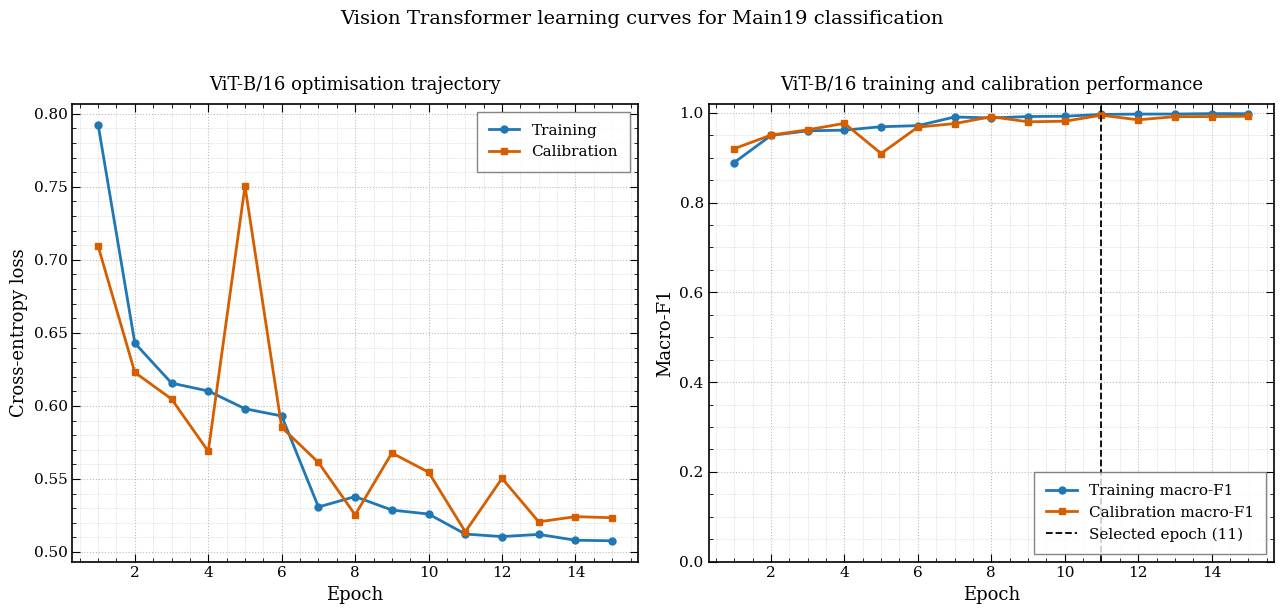

Saved: /kaggle/working/vit_comparison_and_efficiency_outputs/figures/fig_01_vit_learning_curves.png


In [16]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 6)
)

axes[0].plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    markersize=5,
    linewidth=2,
    color="#1F77B4",
    label="Training"
)

axes[0].plot(
    history_df["epoch"],
    history_df["calibration_loss"],
    marker="s",
    markersize=5,
    linewidth=2,
    color="#D55E00",
    label="Calibration"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].set_title("ViT-B/16 optimisation trajectory", pad=10)

paper_axes(axes[0])

axes[0].legend(
    loc="best",
    fancybox=False,
    borderpad=0.8
)

axes[1].plot(
    history_df["epoch"],
    history_df["train_macro_f1"],
    marker="o",
    markersize=5,
    linewidth=2,
    color="#1F77B4",
    label="Training macro-F1"
)

axes[1].plot(
    history_df["epoch"],
    history_df["calibration_macro_f1"],
    marker="s",
    markersize=5,
    linewidth=2,
    color="#D55E00",
    label="Calibration macro-F1"
)

axes[1].axvline(
    best_epoch,
    color="black",
    linestyle="--",
    linewidth=1.3,
    label=f"Selected epoch ({best_epoch})"
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro-F1")
axes[1].set_ylim(0.0, 1.02)

axes[1].set_title(
    "ViT-B/16 training and calibration performance",
    pad=10
)

paper_axes(axes[1])

axes[1].legend(
    loc="lower right",
    fancybox=False,
    borderpad=0.8
)

fig.suptitle(
    "Vision Transformer learning curves for Main19 classification",
    y=1.02,
    fontsize=14
)

plt.tight_layout()

learning_curve_png = FIG_DIR / "fig_01_vit_learning_curves.png"
learning_curve_pdf = FIG_DIR / "fig_01_vit_learning_curves.pdf"

plt.savefig(
    learning_curve_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    learning_curve_pdf,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Saved:", learning_curve_png)

In [17]:
best_checkpoint = torch.load(
    best_checkpoint_path,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(
    best_checkpoint["model_state_dict"]
)

model.eval()

print("Selected checkpoint reloaded.")
print("Best epoch:", best_checkpoint["epoch"])
print(
    "Best calibration macro-F1:",
    round(
        best_checkpoint["best_calibration_macro_f1"],
        6
    )
)

Selected checkpoint reloaded.
Best epoch: 11
Best calibration macro-F1: 0.994692


In [18]:
calibration_metrics, calibration_outputs = evaluate_model(
    model=model,
    loader=calibration_loader,
    criterion=criterion,
    device=DEVICE
)

calibration_metrics_df = pd.DataFrame([{
    "model": "ViT-B/16",
    "split": "calibration",
    "selected_epoch": best_epoch,
    **calibration_metrics
}])

calibration_metrics_path = (
    TABLE_DIR / "vit_calibration_metrics.csv"
)

calibration_metrics_df.to_csv(
    calibration_metrics_path,
    index=False
)

display(calibration_metrics_df)

class_names = [
    index_to_class[index]
    for index in range(NUM_CLASSES)
]

calibration_report = classification_report(
    calibration_outputs["targets"],
    calibration_outputs["predictions"],
    labels=list(range(NUM_CLASSES)),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

calibration_report_df = (
    pd.DataFrame(calibration_report)
    .transpose()
    .reset_index()
    .rename(columns={"index": "class_or_average"})
)

calibration_report_path = (
    TABLE_DIR / "vit_calibration_classification_report.csv"
)

calibration_report_df.to_csv(
    calibration_report_path,
    index=False
)

print("Saved:", calibration_metrics_path)
print("Saved:", calibration_report_path)

Evaluating:   0%|          | 0/200 [00:00<?, ?it/s]

,model,split,selected_epoch,loss,accuracy,balanced_accuracy,macro_f1
0,ViT-B/16,calibration,11,0.513843,0.995934,0.995251,0.994692


Saved: /kaggle/working/vit_comparison_and_efficiency_outputs/tables/vit_calibration_metrics.csv
Saved: /kaggle/working/vit_comparison_and_efficiency_outputs/tables/vit_calibration_classification_report.csv


In [19]:
def count_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
    )


@torch.no_grad()
def benchmark_inference(
    model,
    device,
    image_size,
    batch_size=1,
    warmup_runs=20,
    timed_runs=100
):
    model.eval()

    sample = torch.randn(
        batch_size,
        3,
        image_size,
        image_size,
        device=device
    )

    for _ in range(warmup_runs):
        _ = model(sample)

    torch.cuda.synchronize()

    start_time = time.perf_counter()

    for _ in range(timed_runs):
        _ = model(sample)

    torch.cuda.synchronize()

    elapsed = time.perf_counter() - start_time

    milliseconds_per_batch = (
        elapsed / timed_runs
    ) * 1000

    milliseconds_per_image = (
        milliseconds_per_batch / batch_size
    )

    images_per_second = (
        1000 / milliseconds_per_image
    )

    return {
        "batch_size": batch_size,
        "timed_runs": timed_runs,
        "milliseconds_per_image": milliseconds_per_image,
        "images_per_second": images_per_second
    }


vit_efficiency = benchmark_inference(
    model=model,
    device=DEVICE,
    image_size=IMAGE_SIZE,
    batch_size=1
)

vit_efficiency["model"] = "ViT-B/16"
vit_efficiency["parameters"] = count_parameters(model)
vit_efficiency["parameters_million"] = (
    vit_efficiency["parameters"] / 1e6
)
vit_efficiency["input_size"] = IMAGE_SIZE

vit_efficiency_df = pd.DataFrame([vit_efficiency])

vit_efficiency_path = TABLE_DIR / "vit_efficiency_metrics.csv"
vit_efficiency_df.to_csv(
    vit_efficiency_path,
    index=False
)

display(vit_efficiency_df)
print("Saved:", vit_efficiency_path)

,batch_size,timed_runs,milliseconds_per_image,images_per_second,model,parameters,parameters_million,input_size
0,1,100,17.443963,57.326421,ViT-B/16,85813267,85.813267,224


Saved: /kaggle/working/vit_comparison_and_efficiency_outputs/tables/vit_efficiency_metrics.csv


In [20]:
test_metrics, test_outputs = evaluate_model(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=DEVICE
)

test_metrics_df = pd.DataFrame([{
    "model": "ViT-B/16",
    "split": "internal_test",
    "selected_epoch": best_epoch,
    **test_metrics
}])

test_metrics_path = TABLE_DIR / "vit_internal_test_metrics.csv"

test_metrics_df.to_csv(
    test_metrics_path,
    index=False
)

display(test_metrics_df)

print("Saved:", test_metrics_path)

Evaluating:   0%|          | 0/333 [00:00<?, ?it/s]

,model,split,selected_epoch,loss,accuracy,balanced_accuracy,macro_f1
0,ViT-B/16,internal_test,11,0.729108,0.993611,0.993793,0.992596


Saved: /kaggle/working/vit_comparison_and_efficiency_outputs/tables/vit_internal_test_metrics.csv


In [21]:
test_report = classification_report(
    test_outputs["targets"],
    test_outputs["predictions"],
    labels=list(range(NUM_CLASSES)),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

test_report_df = (
    pd.DataFrame(test_report)
    .transpose()
    .reset_index()
    .rename(columns={"index": "class_or_average"})
)

test_report_path = (
    TABLE_DIR / "vit_test_classification_report.csv"
)

test_report_df.to_csv(
    test_report_path,
    index=False
)

vit_predictions_df = test_df[
    ["image_path", "label"]
].copy()

vit_predictions_df["true_class_index"] = (
    test_outputs["targets"]
)

vit_predictions_df["predicted_class_index"] = (
    test_outputs["predictions"]
)

vit_predictions_df["predicted_label"] = [
    index_to_class[index]
    for index in test_outputs["predictions"]
]

vit_predictions_df["confidence"] = (
    test_outputs["probabilities"].max(axis=1)
)

vit_predictions_df["correct"] = (
    vit_predictions_df["true_class_index"]
    == vit_predictions_df["predicted_class_index"]
)

vit_predictions_path = TABLE_DIR / "vit_test_predictions.csv"

vit_predictions_df.to_csv(
    vit_predictions_path,
    index=False
)

display(test_report_df.head(10))
print("Saved:", test_report_path)
print("Saved:", vit_predictions_path)

,class_or_average,precision,recall,f1-score,support
0,bell_pepper__bacterial_spot,1.000000,0.995000,0.997494,200.0
1,bell_pepper__healthy,1.000000,0.996610,0.998302,295.0
2,corn__cercospora_leaf_spot_gray_leaf_spot,0.971154,0.980583,0.975845,103.0
3,corn__common_rust,1.000000,0.995816,0.997904,239.0
4,corn__healthy,1.000000,1.000000,1.000000,232.0
5,corn__northern_leaf_blight,0.984772,0.984772,0.984772,197.0
6,potato__early_blight,0.995000,1.000000,0.997494,199.0
7,potato__healthy,0.968750,1.000000,0.984127,31.0
8,potato__late_blight,0.995000,0.995000,0.995000,200.0
9,tomato__bacterial_spot,0.988345,0.997647,0.992974,425.0


Saved: /kaggle/working/vit_comparison_and_efficiency_outputs/tables/vit_test_classification_report.csv
Saved: /kaggle/working/vit_comparison_and_efficiency_outputs/tables/vit_test_predictions.csv


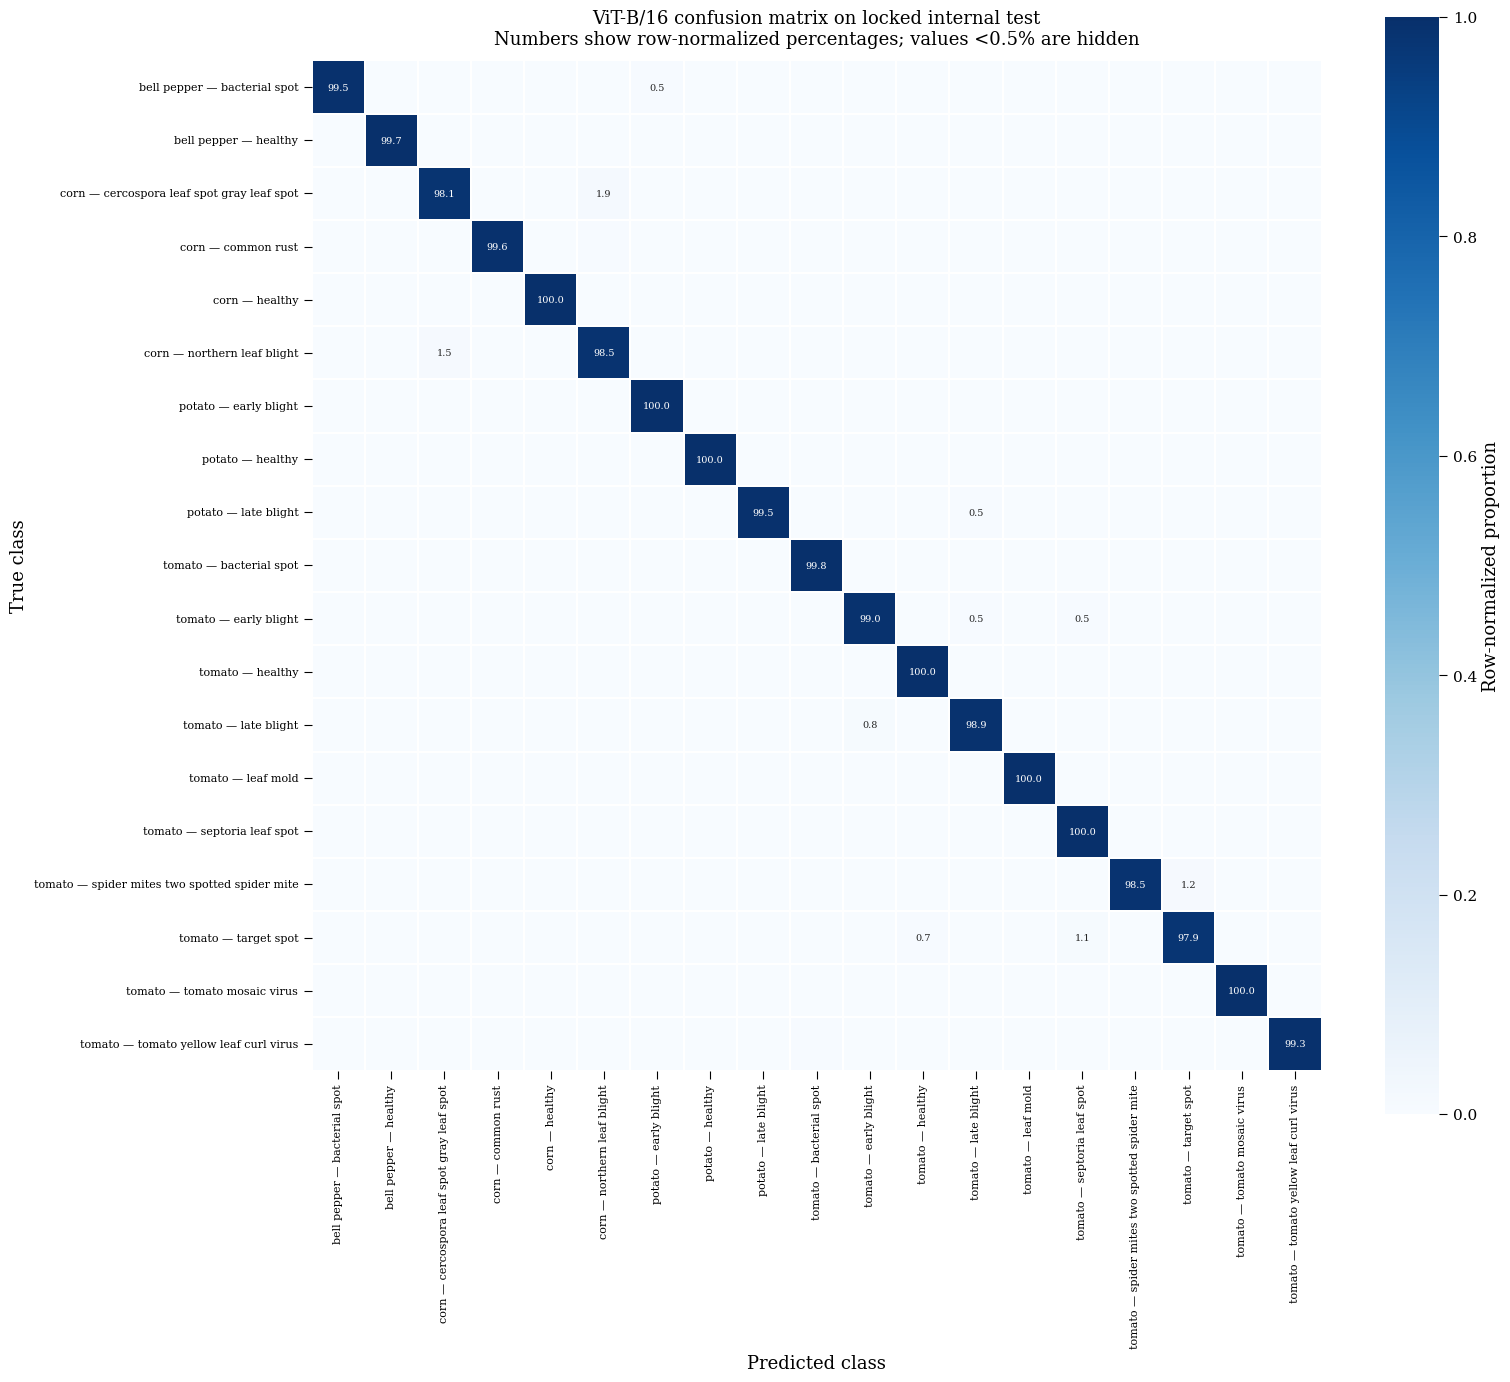

Saved: /kaggle/working/vit_comparison_and_efficiency_outputs/figures/fig_02_vit_test_confusion_matrix_numeric.png


In [22]:
readable_class_names = [
    class_name
    .replace("__", " — ")
    .replace("_", " ")
    for class_name in class_names
]

confusion = confusion_matrix(
    test_outputs["targets"],
    test_outputs["predictions"],
    labels=list(range(NUM_CLASSES)),
    normalize="true"
)

annotation_labels = np.empty_like(
    confusion,
    dtype=object
)

for row_index in range(NUM_CLASSES):
    for column_index in range(NUM_CLASSES):
        value = confusion[row_index, column_index]

        if value >= 0.005:
            annotation_labels[row_index, column_index] = (
                f"{value * 100:.1f}"
            )
        else:
            annotation_labels[row_index, column_index] = ""

fig, ax = plt.subplots(figsize=(16, 14))

sns.heatmap(
    confusion,
    annot=annotation_labels,
    fmt="",
    cmap="Blues",
    vmin=0.0,
    vmax=1.0,
    linewidths=0.35,
    linecolor="white",
    square=True,
    cbar_kws={
        "label": "Row-normalized proportion"
    },
    xticklabels=readable_class_names,
    yticklabels=readable_class_names,
    ax=ax,
    annot_kws={
        "fontsize": 7
    }
)

ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")

ax.set_title(
    "ViT-B/16 confusion matrix on locked internal test\n"
    "Numbers show row-normalized percentages; values <0.5% are hidden",
    pad=12
)

ax.set_xticklabels(
    readable_class_names,
    rotation=90,
    ha="center",
    fontsize=8
)

ax.set_yticklabels(
    readable_class_names,
    rotation=0,
    fontsize=8
)

for spine in ax.spines.values():
    spine.set_linewidth(1.2)

plt.tight_layout()

confusion_png = FIG_DIR / "fig_02_vit_test_confusion_matrix_numeric.png"
confusion_pdf = FIG_DIR / "fig_02_vit_test_confusion_matrix_numeric.pdf"

plt.savefig(
    confusion_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    confusion_pdf,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Saved:", confusion_png)

In [23]:
confusion_counts = confusion_matrix(
    test_outputs["targets"],
    test_outputs["predictions"],
    labels=list(range(NUM_CLASSES))
)

error_rows = []

for true_index in range(NUM_CLASSES):
    for predicted_index in range(NUM_CLASSES):
        if true_index == predicted_index:
            continue

        count = confusion_counts[
            true_index,
            predicted_index
        ]

        if count > 0:
            error_rows.append({
                "true_class": index_to_class[true_index],
                "predicted_class": index_to_class[predicted_index],
                "misclassified_images": int(count),
                "true_class_support": int(
                    confusion_counts[true_index].sum()
                ),
                "row_error_rate_percent": (
                    count / confusion_counts[true_index].sum()
                ) * 100
            })

top_confusions_df = (
    pd.DataFrame(error_rows)
    .sort_values(
        "misclassified_images",
        ascending=False
    )
    .reset_index(drop=True)
)

top_confusions_path = (
    TABLE_DIR / "vit_top_confusion_pairs.csv"
)

top_confusions_df.to_csv(
    top_confusions_path,
    index=False
)

display(top_confusions_df.head(20))
print("Saved:", top_confusions_path)

,true_class,predicted_class,misclassified_images,true_class_support,row_error_rate_percent
0,tomato__tomato_yellow_leaf_curl_virus,tomato__bacterial_spot,5,1071,0.466853
1,tomato__spider_mites_two_spotted_spider_mite,tomato__target_spot,4,335,1.194030
2,corn__northern_leaf_blight,corn__cercospora_leaf_spot_gray_leaf_spot,3,197,1.522843
3,tomato__target_spot,tomato__septoria_leaf_spot,3,281,1.067616
4,tomato__late_blight,tomato__early_blight,3,379,0.791557
5,corn__cercospora_leaf_spot_gray_leaf_spot,corn__northern_leaf_blight,2,103,1.941748
6,tomato__target_spot,tomato__healthy,2,281,0.711744
7,bell_pepper__healthy,potato__healthy,1,295,0.338983
8,bell_pepper__bacterial_spot,potato__early_blight,1,200,0.500000
9,potato__late_blight,tomato__late_blight,1,200,0.500000


Saved: /kaggle/working/vit_comparison_and_efficiency_outputs/tables/vit_top_confusion_pairs.csv


In [24]:
comparison_rows = []

if BASELINE_METRICS_PATH is not None:
    baseline_metrics_df = pd.read_csv(
        BASELINE_METRICS_PATH
    )

    baseline_test_row = baseline_metrics_df[
        baseline_metrics_df["split"] == "test_temperature_scaled"
    ].copy()

    if len(baseline_test_row) == 0:
        baseline_test_row = baseline_metrics_df[
            baseline_metrics_df["split"] == "test_uncalibrated"
        ].copy()

    baseline_test_row["model"] = "EfficientNet-B0"
    baseline_test_row["model_family"] = "CNN"
    comparison_rows.append(baseline_test_row)

if PROPOSED_METRICS_PATH is not None:
    proposed_metrics_df = pd.read_csv(
        PROPOSED_METRICS_PATH
    )

    proposed_test_row = proposed_metrics_df[
        proposed_metrics_df["split"] == "test_uncalibrated"
    ].copy()

    proposed_test_row["model"] = "EfficientNetV2-S"
    proposed_test_row["model_family"] = "CNN"
    comparison_rows.append(proposed_test_row)

vit_comparison_row = test_metrics_df.copy()
vit_comparison_row["nll"] = log_loss(
    test_outputs["targets"],
    test_outputs["probabilities"],
    labels=list(range(NUM_CLASSES))
)

one_hot_targets = np.eye(NUM_CLASSES)[
    test_outputs["targets"]
]

vit_comparison_row["brier"] = np.mean(
    np.sum(
        (
            test_outputs["probabilities"]
            - one_hot_targets
        ) ** 2,
        axis=1
    )
)

vit_comparison_row["model_family"] = "Transformer"
comparison_rows.append(vit_comparison_row)

model_comparison_df = pd.concat(
    comparison_rows,
    ignore_index=True
)

comparison_columns = [
    "model",
    "model_family",
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "nll",
    "brier",
    "loss"
]

comparison_columns = [
    column
    for column in comparison_columns
    if column in model_comparison_df.columns
]

model_comparison_df = model_comparison_df[
    comparison_columns
].copy()

model_comparison_path = (
    TABLE_DIR / "cnn_vs_vit_internal_test_comparison.csv"
)

model_comparison_df.to_csv(
    model_comparison_path,
    index=False
)

display(model_comparison_df)
print("Saved:", model_comparison_path)

,model,model_family,accuracy,balanced_accuracy,macro_f1,nll,brier,loss
0,EfficientNet-B0,CNN,0.995490,0.993468,0.993139,0.015896,0.000337,NaN
1,EfficientNetV2-S,CNN,0.995490,0.993544,0.992649,0.017609,0.007734,NaN
2,ViT-B/16,Transformer,0.993611,0.993793,0.992596,0.148108,0.031062,0.729108


Saved: /kaggle/working/vit_comparison_and_efficiency_outputs/tables/cnn_vs_vit_internal_test_comparison.csv


In [25]:
efficiency_rows = [
    {
        "model": "ViT-B/16",
        "parameters_million": vit_efficiency[
            "parameters_million"
        ],
        "input_size": vit_efficiency["input_size"],
        "milliseconds_per_image": vit_efficiency[
            "milliseconds_per_image"
        ],
        "images_per_second": vit_efficiency[
            "images_per_second"
        ]
    }
]

efficiency_df = pd.DataFrame(efficiency_rows)

efficiency_comparison_path = (
    TABLE_DIR / "vit_efficiency_comparison.csv"
)

efficiency_df.to_csv(
    efficiency_comparison_path,
    index=False
)

display(efficiency_df)
print("Saved:", efficiency_comparison_path)

print(
    "\nNote: EfficientNet latency/parameter figures should be generated "
    "from their original model checkpoints in Notebook 12 for a fully "
    "controlled hardware comparison."
)

,model,parameters_million,input_size,milliseconds_per_image,images_per_second
0,ViT-B/16,85.813267,224,17.443963,57.326421


Saved: /kaggle/working/vit_comparison_and_efficiency_outputs/tables/vit_efficiency_comparison.csv

Note: EfficientNet latency/parameter figures should be generated from their original model checkpoints in Notebook 12 for a fully controlled hardware comparison.


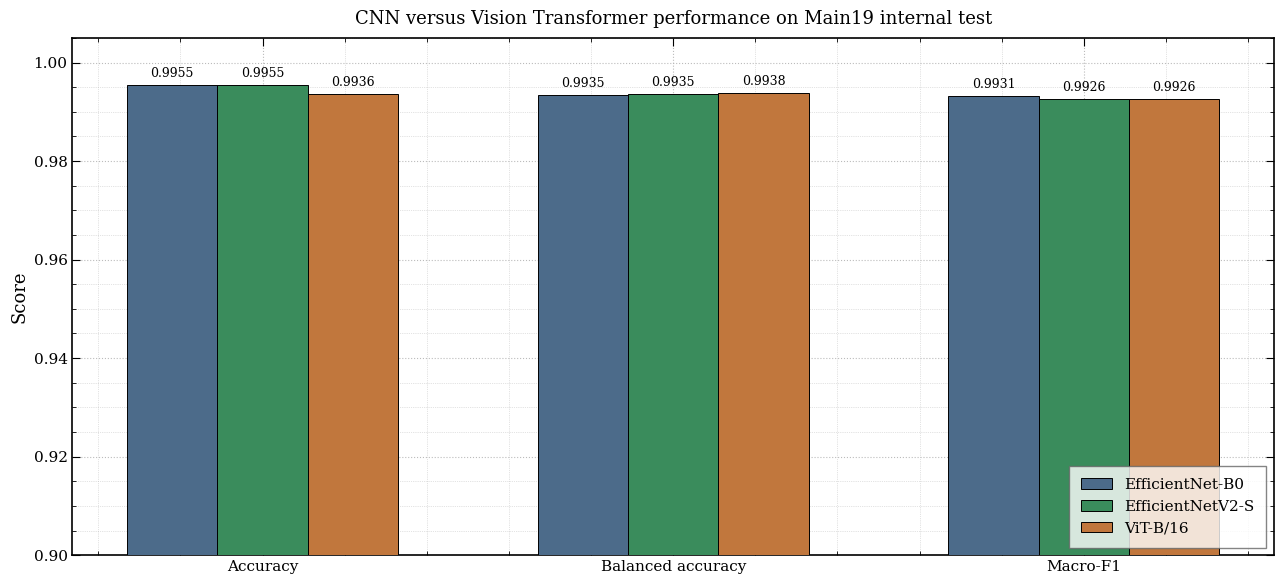

Saved: /kaggle/working/vit_comparison_and_efficiency_outputs/figures/fig_03_cnn_vs_vit_test_comparison.png


In [26]:
plot_metrics = [
    "accuracy",
    "balanced_accuracy",
    "macro_f1"
]

plot_df = model_comparison_df[
    ["model"] + plot_metrics
].melt(
    id_vars="model",
    var_name="metric",
    value_name="score"
)

fig, ax = plt.subplots(figsize=(13, 6))

models_order = list(
    model_comparison_df["model"]
)

metrics_order = [
    "accuracy",
    "balanced_accuracy",
    "macro_f1"
]

bar_width = 0.22
x_positions = np.arange(len(metrics_order))

palette = {
    "EfficientNet-B0": "#4C6B8A",
    "EfficientNetV2-S": "#3A8C5C",
    "ViT-B/16": "#C1773D"
}

for model_position, model_name in enumerate(models_order):
    subset = (
        plot_df[
            plot_df["model"] == model_name
        ]
        .set_index("metric")
        .reindex(metrics_order)
    )

    bar_positions = (
        x_positions
        + model_position * bar_width
    )

    ax.bar(
        bar_positions,
        subset["score"],
        width=bar_width,
        label=model_name,
        color=palette.get(model_name, "#777777"),
        edgecolor="black",
        linewidth=0.7,
        zorder=3
    )

    for x, value in zip(
        bar_positions,
        subset["score"]
    ):
        ax.text(
            x,
            value + 0.001,
            f"{value:.4f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

ax.set_xticks(
    x_positions
    + (len(models_order) - 1) * bar_width / 2
)

ax.set_xticklabels([
    "Accuracy",
    "Balanced accuracy",
    "Macro-F1"
])

ax.set_ylim(0.90, 1.005)
ax.set_ylabel("Score")

ax.set_title(
    "CNN versus Vision Transformer performance on Main19 internal test",
    pad=10
)

paper_axes(ax)

ax.legend(
    loc="lower right",
    fancybox=False,
    borderpad=0.8
)

plt.tight_layout()

comparison_png = FIG_DIR / "fig_03_cnn_vs_vit_test_comparison.png"
comparison_pdf = FIG_DIR / "fig_03_cnn_vs_vit_test_comparison.pdf"

plt.savefig(
    comparison_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    comparison_pdf,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Saved:", comparison_png)

In [27]:
run_metadata = {
    "notebook": "07_vit_comparison_and_efficiency",
    "completed_utc": datetime.now(timezone.utc).isoformat(),
    "model": "ViT-B/16",
    "best_epoch": int(best_epoch),
    "best_calibration_macro_f1": float(best_macro_f1),
    "internal_test_metrics": {
        key: float(value)
        for key, value in test_metrics.items()
    },
    "checkpoint_path": str(best_checkpoint_path),
    "confirmed_near_duplicate_exclusions": data_protocol.get(
        "confirmed_near_duplicate_exclusions",
        "not_recorded"
    ),
    "python_version": platform.python_version(),
    "torch_version": torch.__version__,
    "torchvision_version": __import__(
        "torchvision"
    ).__version__,
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__
}

run_metadata_path = (
    METADATA_DIR / "vit_run_metadata.json"
)

with open(run_metadata_path, "w") as file:
    json.dump(run_metadata, file, indent=2)

assert best_checkpoint_path.exists()
assert history_path.exists()
assert test_metrics_path.exists()
assert test_report_path.exists()
assert vit_predictions_path.exists()
assert run_metadata_path.exists()

print(json.dumps(run_metadata, indent=2))

print("\n" + "=" * 78)
print("NOTEBOOK 07 COMPLETED")
print("=" * 78)

print("\nViT-B/16 final internal-test performance")
print("Accuracy:", round(test_metrics["accuracy"], 5))
print(
    "Balanced accuracy:",
    round(test_metrics["balanced_accuracy"], 5)
)
print("Macro-F1:", round(test_metrics["macro_f1"], 5))

print("\nOutput directory:")
print(OUTPUT_DIR)

print("\nNext notebook:")
print("08_calibration_and_selective_prediction")

{
  "notebook": "07_vit_comparison_and_efficiency",
  "completed_utc": "2026-08-22T13:52:05.205585+00:00",
  "model": "ViT-B/16",
  "best_epoch": 11,
  "best_calibration_macro_f1": 0.994691549866515,
  "internal_test_metrics": {
    "loss": 0.729107640988842,
    "accuracy": 0.9936114242765878,
    "balanced_accuracy": 0.9937926053709886,
    "macro_f1": 0.9925955689485293
  },
  "checkpoint_path": "/kaggle/working/vit_comparison_and_efficiency_outputs/checkpoints/best_vit_b16_main19.pt",
  "confirmed_near_duplicate_exclusions": 2,
  "python_version": "3.12.13",
  "torch_version": "2.10.0+cu128",
  "torchvision_version": "0.25.0+cu128",
  "numpy_version": "2.0.2",
  "pandas_version": "2.3.3"
}

NOTEBOOK 07 COMPLETED

ViT-B/16 final internal-test performance
Accuracy: 0.99361
Balanced accuracy: 0.99379
Macro-F1: 0.9926

Output directory:
/kaggle/working/vit_comparison_and_efficiency_outputs

Next notebook:
08_calibration_and_selective_prediction


In [28]:
vit_calibration_predictions_df = calibration_df[
    ["image_path", "label"]
].copy()

vit_calibration_predictions_df["true_class_index"] = (
    calibration_outputs["targets"]
)

vit_calibration_predictions_df["predicted_class_index"] = (
    calibration_outputs["predictions"]
)

vit_calibration_predictions_df["predicted_label"] = [
    index_to_class[index]
    for index in calibration_outputs["predictions"]
]

vit_calibration_predictions_df["confidence"] = (
    calibration_outputs["probabilities"].max(axis=1)
)

vit_calibration_predictions_df["correct"] = (
    vit_calibration_predictions_df["true_class_index"]
    == vit_calibration_predictions_df["predicted_class_index"]
)

for class_index in range(NUM_CLASSES):
    class_name = index_to_class[class_index]
    safe_name = (
        class_name
        .replace("__", "_")
        .replace(" ", "_")
    )

    vit_calibration_predictions_df[
        f"probability_{class_index:02d}_{safe_name}"
    ] = calibration_outputs["probabilities"][:, class_index]

vit_calibration_predictions_path = (
    TABLE_DIR / "vit_calibration_predictions.csv"
)

vit_calibration_predictions_df.to_csv(
    vit_calibration_predictions_path,
    index=False
)

print("Saved:", vit_calibration_predictions_path)

display(
    vit_calibration_predictions_df[
        [
            "label",
            "predicted_label",
            "confidence",
            "correct"
        ]
    ].head()
)

Saved: /kaggle/working/vit_comparison_and_efficiency_outputs/tables/vit_calibration_predictions.csv


/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,label,predicted_label,confidence,correct
0,potato__early_blight,potato__early_blight,0.944824,True
1,corn__healthy,corn__healthy,0.934082,True
2,tomato__late_blight,tomato__late_blight,0.895996,True
3,tomato__spider_mites_two_spotted_spider_mite,tomato__spider_mites_two_spotted_spider_mite,0.909668,True
4,tomato__tomato_yellow_leaf_curl_virus,tomato__tomato_yellow_leaf_curl_virus,0.741211,True
